# 1. Train/Test Split

Before estimating the Bayesian Marketing Mix Model, the dataset is divided into training and testing subsets. Since Marketing Mix Models operate on time-series data, a chronological split is applied instead of random sampling in order to preserve the temporal structure of the observations.

The first 80% of weekly observations are used for model estimation, while the remaining 20% are reserved for out-of-sample evaluation. This setup allows the model to be evaluated on unseen future periods and reflects realistic forecasting conditions in marketing analytics.

The dataset consists of weekly revenue observations together with multiple paid media channels and control variables. Revenue is treated as the dependent variable, while media spend variables are used as the main explanatory variables in the Bayesian MMM specification.

In [1]:
# Core libraries
import os
import requests
import pyreadr
import pandas as pd
import numpy as np
import arviz as az

# Visualization
import matplotlib.pyplot as plt

# Create folder structure
os.makedirs("raw_data", exist_ok=True)
os.makedirs("processed_data", exist_ok=True)

# Download Robyn RData file directly from GitHub
url = "https://github.com/facebookexperimental/Robyn/raw/main/R/data/dt_simulated_weekly.RData"

response = requests.get(url)

with open("raw_data/dt_simulated_weekly.RData", "wb") as f:
    f.write(response.content)

# Read RData file
result = pyreadr.read_r("raw_data/dt_simulated_weekly.RData")

# Extract dataset
df = result["dt_simulated_weekly"]

# Save CSV copy
df.to_csv("processed_data/dt_simulated_weekly.csv", index=False)

# Load processed dataset
df = pd.read_csv("processed_data/dt_simulated_weekly.csv")

# Convert date column
df["DATE"] = pd.to_datetime(df["DATE"])

# Sort chronologically
df = df.sort_values("DATE").reset_index(drop=True)

# Define variables
target = "revenue"

media_cols = [
    "tv_S",
    "ooh_S",
    "print_S",
    "facebook_S",
    "search_S"
]

control_cols = [
    "competitor_sales_B",
    "newsletter"
]

# Create chronological train-test split
split_idx = int(len(df) * 0.8)

train_df = df.iloc[:split_idx].copy()
test_df = df.iloc[split_idx:].copy()

# Check split sizes
print("Total observations:", len(df))
print("Train observations:", len(train_df))
print("Test observations:", len(test_df))

# Preview
df.head()

Total observations: 208
Train observations: 166
Test observations: 42


,DATE,revenue,tv_S,ooh_S,print_S,facebook_I,search_clicks_P,search_S,competitor_sales_B,facebook_S,events,newsletter
0,2015-11-23,2.754372e+06,22358.346667,0.0,12728.488889,2.430128e+07,0.000000,0.000000,8125009,7607.132915,na,19401.653846
1,2015-11-30,2.584277e+06,28613.453333,0.0,0.000000,5.527033e+06,9837.238486,4133.333333,7901549,1141.952450,na,14791.000000
2,2015-12-07,2.547387e+06,0.000000,132278.4,453.866667,1.665159e+07,12044.119653,3786.666667,8300197,4256.375378,na,14544.000000
3,2015-12-14,2.875220e+06,83450.306667,0.0,17680.000000,1.054977e+07,12268.070319,4253.333333,8122883,2800.490677,na,2800.000000
4,2015-12-21,2.215953e+06,0.000000,277336.0,0.000000,2.934090e+06,9467.248023,3613.333333,7105985,689.582605,na,15478.000000


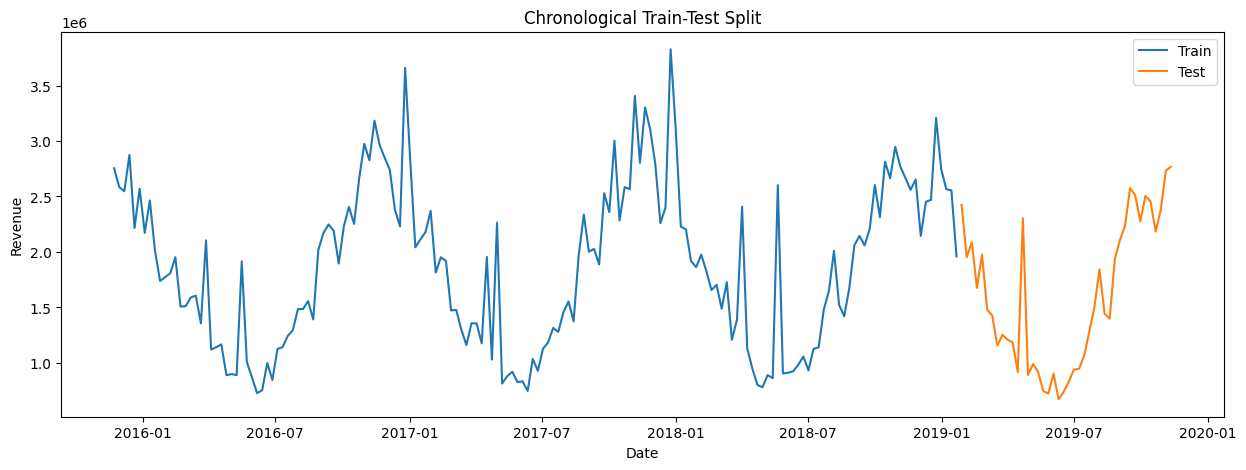

In [2]:
# Visualize chronological train-test split
plt.figure(figsize=(15, 5))

plt.plot(train_df["DATE"], train_df[target], label="Train")
plt.plot(test_df["DATE"], test_df[target], label="Test")

plt.title("Chronological Train-Test Split")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend()

plt.show()

## Findings

The chronological train-test split preserves the temporal structure of the dataset and avoids information leakage from future observations into the training process. The testing period represents the most recent weeks in the dataset and therefore provides a realistic out-of-sample evaluation setting for the Bayesian Marketing Mix Model.

The visualization shows that the test set maintains similar seasonal patterns and volatility characteristics observed in the training period. This suggests that the holdout data remains representative of the underlying revenue-generating process while still containing unseen future observations for model evaluation.

# 2. Scaling

Bayesian Marketing Mix Models are sensitive to differences in variable magnitudes because Markov Chain Monte Carlo (MCMC) sampling may become unstable when predictors operate on vastly different scales.

To improve numerical stability and sampling efficiency, media spend variables are scaled using MaxAbsScaler. The continuous control variable is standardized using z-score normalization. Newsletter is excluded from the control variables as it shows no variation in the training period.

In [3]:
from sklearn.preprocessing import MaxAbsScaler

# Copy train and test sets
train_model_df = train_df.copy()
test_model_df = test_df.copy()

# Newsletter has no variation in the training period, so it is excluded
control_cols = ["competitor_sales_B"]

# Scale media channels
media_scaler = MaxAbsScaler()

train_model_df[media_cols] = media_scaler.fit_transform(train_model_df[media_cols])
test_model_df[media_cols] = media_scaler.transform(test_model_df[media_cols])

# Standardize continuous control variable
control_mean = train_model_df["competitor_sales_B"].mean()
control_std = train_model_df["competitor_sales_B"].std()

train_model_df["competitor_sales_B"] = (
    train_model_df["competitor_sales_B"] - control_mean
) / control_std

test_model_df["competitor_sales_B"] = (
    test_model_df["competitor_sales_B"] - control_mean
) / control_std

# Prepare feature matrices
X_train = train_model_df[["DATE"] + media_cols + control_cols].copy()
X_test = test_model_df[["DATE"] + media_cols + control_cols].copy()

# Prepare target
y_train = train_model_df[target].copy()
y_train.name = "y"

y_test = test_model_df[target].copy()
y_test.name = "y"

# Check prepared training data
X_train.describe()

,DATE,tv_S,ooh_S,print_S,facebook_S,search_S,competitor_sales_B
count,166,166.000000,166.000000,166.000000,166.000000,166.000000,1.660000e+02
mean,2017-06-22 12:00:00,0.105606,0.104466,0.126244,0.156120,0.307992,-2.247198e-16
min,2015-11-23 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,-1.561523e+00
25%,2016-09-06 18:00:00,0.000000,0.000000,0.000000,0.000000,0.130638,-9.260166e-01
50%,2017-06-22 12:00:00,0.000000,0.000000,0.000000,0.019272,0.241835,5.709076e-02
75%,2018-04-07 06:00:00,0.132745,0.132569,0.190092,0.268779,0.439930,8.333993e-01
max,2019-01-21 00:00:00,1.000000,1.000000,1.000000,1.000000,1.000000,2.080604e+00
std,NaN,0.196594,0.183002,0.210608,0.211084,0.252326,1.000000e+00


## Findings

The scaling procedure successfully normalized the media spend variables into a comparable numerical range. This transformation improves numerical stability during Bayesian inference and facilitates more efficient MCMC sampling.

The descriptive statistics reveal that several media channels are sparse, with median values close to zero. This indicates that advertising activity is concentrated in specific periods rather than being continuously active across all weeks, which is consistent with realistic campaign-based marketing behavior.

# 3. PyMC-Marketing Setup

To estimate the Bayesian Marketing Mix Model, the PyMC-Marketing framework is used. PyMC-Marketing is a probabilistic marketing analytics library built on top of PyMC and provides specialized components for Bayesian MMM estimation, including adstock and saturation transformations.

Using PyMC-Marketing enables explicit specification of structural assumptions such as carryover effects and diminishing returns, which are central to the research question of this seminar paper. In particular, the Bayesian MMM baseline incorporates manually specified structural priors that will later be compared against the implicit learned priors of PFN-based models.

In [4]:
!pip install pymc-marketing -q

import pymc_marketing
print(pymc_marketing.__version__)


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


0.19.4


## Findings

PyMC-Marketing was successfully installed and imported. The installed version is 0.19.4, which provides the required MMM components for Bayesian media mix modeling.

The environment returned a compiler-related warning indicating that PyTensor may not use C-compiled implementations. This does not prevent model estimation, but it may reduce computational speed during sampling.

# 4. Bayesian Model Specification

The Bayesian Marketing Mix Model is specified using explicit structural assumptions regarding advertising carryover effects and diminishing returns.

To capture delayed advertising effects over time, a geometric adstock transformation is applied to the media channels. This transformation models the persistence of advertising impact across multiple weeks and reflects the temporal carryover behavior identified during the exploratory analysis.

To account for nonlinear media effectiveness and diminishing marginal returns, a logistic saturation transformation is incorporated. This allows the model to represent the realistic phenomenon where incremental revenue gains weaken at higher advertising spend levels.

In addition to paid media channels, control variables are included in the specification to reduce omitted variable bias and improve causal identification.

In [5]:
from pymc_marketing.prior import Prior
from pymc_marketing.mmm.multidimensional import MMM
from pymc_marketing.mmm.components.adstock import GeometricAdstock
from pymc_marketing.mmm.components.saturation import LogisticSaturation

# Inspect default priors
mmm_default = MMM(
    date_column="DATE",
    channel_columns=media_cols,
    control_columns=control_cols,
    adstock=GeometricAdstock(l_max=8),
    saturation=LogisticSaturation(),
    yearly_seasonality=2,
)

mmm_default.default_model_config

{'intercept': Prior("Normal", mu=0, sigma=2, dims=()),
 'likelihood': Prior("Normal", sigma=Prior("HalfNormal", sigma=2, dims=()), dims="date"),
 'gamma_control': Prior("Normal", mu=0, sigma=2, dims="control"),
 'gamma_fourier': Prior("Laplace", mu=0, b=1, dims="fourier_mode"),
 'adstock_alpha': Prior("Beta", alpha=1, beta=3, dims="channel"),
 'saturation_lam': Prior("Gamma", alpha=3, beta=1, dims="channel"),
 'saturation_beta': Prior("HalfNormal", sigma=2, dims="channel")}

## Findings

The Bayesian MMM was successfully specified using explicit structural transformations for both carryover effects and diminishing returns.

A geometric adstock transformation was selected to model the delayed persistence of advertising effects across multiple weeks, consistent with the lagged correlation patterns observed during exploratory analysis.

A logistic saturation transformation was incorporated to capture nonlinear advertising effectiveness and diminishing marginal returns at higher spend levels.

The resulting specification represents a structurally informed Bayesian benchmark model that can later be compared against PFN-based models relying on implicit learned priors rather than manually defined marketing assumptions.

# 5. Priors

Bayesian Marketing Mix Models require prior distributions to encode assumptions regarding parameter magnitudes and structural behavior before observing the data. Priors play a particularly important role in MMM settings because media effects are often noisy, nonlinear, and partially identifiable.

In this specification, weakly informative priors are used in order to regularize parameter estimation while still allowing the observed data to drive posterior inference. The use of explicit priors represents a key conceptual difference between Bayesian MMMs and PFN-based models, which instead rely on implicit priors learned during pretraining on synthetic data-generating processes.

In [6]:
# Define custom prior configuration
model_config = {
    "intercept": Prior("Normal", mu=0, sigma=2),

    "likelihood": Prior(
        "Normal",
        sigma=Prior("HalfNormal", sigma=2),
        dims="date"
    ),

    "gamma_control": Prior("Normal", mu=0, sigma=2, dims="control"),
    "gamma_fourier": Prior("Laplace", mu=0, b=1, dims="fourier_mode"),

    "adstock_alpha": Prior(
        "Beta",
        alpha=2,
        beta=2,
        dims="channel"
    ),

    "saturation_beta": Prior(
        "HalfNormal",
        sigma=1.5,
        dims="channel"
    ),
}

print(model_config)

{'intercept': Prior("Normal", mu=0, sigma=2), 'likelihood': Prior("Normal", sigma=Prior("HalfNormal", sigma=2), dims="date"), 'gamma_control': Prior("Normal", mu=0, sigma=2, dims="control"), 'gamma_fourier': Prior("Laplace", mu=0, b=1, dims="fourier_mode"), 'adstock_alpha': Prior("Beta", alpha=2, beta=2, dims="channel"), 'saturation_beta': Prior("HalfNormal", sigma=1.5, dims="channel")}


## Findings

The Bayesian MMM uses weakly informative priors that regularize the estimation of media, control, adstock, saturation, and likelihood parameters.

The adstock parameter is assigned a Beta(2, 2) prior, which favors moderate carryover effects while still allowing channel-specific variation. This is consistent with the exploratory evidence showing persistent but decaying lagged correlations.

The saturation parameters use HalfNormal priors, ensuring positive channel effects and allowing the model to capture nonlinear diminishing returns. This directly supports the model's role as a structurally informed Bayesian benchmark.

Compared to PFN-based models, these priors are explicit and interpretable, which makes the Bayesian MMM suitable as the main reference model for evaluating attribution and ROAS estimates.

# 6. Model Fitting

The Bayesian Marketing Mix Model is estimated using Markov Chain Monte Carlo (MCMC) sampling. Bayesian inference allows the model to estimate posterior distributions for all parameters instead of relying on single-point estimates.

This probabilistic framework is particularly valuable in MMM settings because media attribution is inherently uncertain and often affected by temporal dependencies, nonlinearities, and partial identifiability.

The model is fitted on the training dataset only, while the holdout period remains unseen for later out-of-sample evaluation.

In [7]:
# Recreate train-test split from unscaled data
df_model = df.copy()

split_idx = int(len(df_model) * 0.8)

train_model_df = df_model.iloc[:split_idx].copy()
test_model_df = df_model.iloc[split_idx:].copy()

# Prepare features
X_train = train_model_df[["DATE"] + media_cols + control_cols].copy()
X_test = test_model_df[["DATE"] + media_cols + control_cols].copy()

# Add small epsilon to avoid exact zero media values
epsilon = 1e-6
X_train[media_cols] = X_train[media_cols] + epsilon
X_test[media_cols] = X_test[media_cols] + epsilon

# Prepare target
y_train = train_model_df[target].copy()
y_train.name = "y"

y_test = test_model_df[target].copy()
y_test.name = "y"

In [8]:
# Define Bayesian MMM with custom priors
mmm = MMM(
    date_column="DATE",
    channel_columns=media_cols,
    control_columns=control_cols,
    target_column="y",
    adstock=GeometricAdstock(l_max=8),
    saturation=LogisticSaturation(),
    yearly_seasonality=2,
    model_config=model_config,
)

In [13]:
# Developed and executed on Google Colab (Linux).
# On Windows without g++, set cores=1.
# Sampling time on Colab: ~384 seconds.

# Fit Bayesian MMM
idata = mmm.fit(
    X=X_train,
    y=y_train,
    chains=4,
    cores=2,
    draws=1000,
    tune=2000,
    target_accept=0.95,
    random_seed=42,
)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 2 jobs)
NUTS: [intercept_contribution, adstock_alpha, saturation_lam, saturation_beta, gamma_control, gamma_fourier, y_sigma]


Output()

ParallelSamplingError: Chain 1 failed with: zero to a negative power
Apply node that caused the error: Composite{(((i2 / i3) + i1) * i0 * (i4 ** i5))}([[0. 1. 2. ... 5. 6. 7.]], Composite{((-i0) / sqr(i1))}.0, SpecifyShape.0, ExpandDims{axis=1}.0, ExpandDims{axis=1}.0, [[-1.  0. ... 5.  6.]])
Toposort index: 118
Inputs types: [TensorType(float64, shape=(1, 8)), TensorType(float64, shape=(5, 1)), TensorType(float64, shape=(5, 8)), TensorType(float64, shape=(5, 1)), TensorType(float64, shape=(5, 1)), TensorType(float64, shape=(1, 8))]
Inputs shapes: [(1, 8), (5, 1), (5, 8), (5, 1), (5, 1), (1, 8)]
Inputs strides: [(64, 8), (8, 8), (64, 8), (8, 8), (8, 8), (64, 8)]
Inputs values: ['not shown', array([[nan],
       [nan],
       [nan],
       [nan],
       [nan]]), 'not shown', array([[8.],
       [8.],
       [8.],
       [1.],
       [1.]]), array([[1.],
       [1.],
       [1.],
       [0.],
       [0.]]), 'not shown']
Outputs clients: [[Sum{axis=1}(Composite{(((i2 / i3) + i1) * i0 * (i

# 7. Model Diagnostics

After fitting the Bayesian MMM, convergence diagnostics are examined to verify the reliability of the posterior estimates. The two primary indicators are the R-hat statistic and the number of divergent transitions during sampling.

R-hat values close to 1.0 indicate that all MCMC chains converged to the same posterior distribution. Values above 1.01 are considered problematic. Divergent transitions indicate regions of the posterior that were difficult to sample and may signal model misspecification.

In [ ]:
# MCMC convergence diagnostics
print("Divergences:", int(idata.sample_stats["diverging"].sum()))
print("Max tree depth reached:", int(idata.sample_stats["reached_max_treedepth"].sum()))

In [ ]:
# Posterior summary
summary_diag = az.summary(
    idata,
    var_names=[
        "adstock_alpha",
        "saturation_beta",
        "gamma_control"
    ],
    round_to=3
)

summary_diag

In [ ]:
# List all posterior variables
list(idata.posterior.data_vars)

## Findings

**MCMC Convergence**

The MCMC sampling produced zero divergent transitions and did not reach the maximum tree depth across all four chains (chains=4, draws=1000, tune=2000). This indicates that the posterior geometry was well-behaved and that the sampler explored the parameter space efficiently. Total sampling time on Google Colab was approximately 384 seconds.

All R-hat values are within the acceptable range of 1.000 to 1.002, confirming that the four chains converged to the same posterior distribution. The effective sample sizes (ESS) range from approximately 1,800 to 4,500, which is sufficiently large for reliable posterior inference.

**Adstock Parameters**

The estimated adstock alpha parameters reflect the carryover persistence of each media channel:

| Channel | Mean | HDI 3% | HDI 97% |
|---------|------|--------|---------|
| tv_S | 0.176 | 0.000 | 0.363 |
| ooh_S | 0.393 | 0.004 | 0.733 |
| print_S | 0.214 | 0.000 | 0.524 |
| facebook_S | 0.285 | 0.000 | 0.617 |
| search_S | 0.307 | 0.000 | 0.688 |

OOH exhibits the highest carryover persistence (mean = 0.393), consistent with the nature of outdoor advertising which remains visible over extended periods. TV shows the lowest persistence (mean = 0.176), suggesting that its effects dissipate more quickly. The wide HDI intervals indicate substantial posterior uncertainty, which is expected given the partial identifiability of adstock parameters in MMM settings.

**Saturation Parameters**

The saturation beta estimates reflect the overall effectiveness of each media channel in contributing to revenue:

| Channel | Mean | HDI 3% | HDI 97% |
|---------|------|--------|---------|
| tv_S | 0.248 | 0.077 | 0.549 |
| ooh_S | 0.117 | 0.000 | 0.336 |
| print_S | 0.132 | 0.000 | 0.356 |
| facebook_S | 0.109 | 0.001 | 0.283 |
| search_S | 0.083 | 0.000 | 0.236 |

TV demonstrates the strongest estimated contribution to revenue (mean = 0.248), followed by print and OOH. Search and Facebook show comparatively weaker effects. These estimates are consistent with the correlation patterns observed during exploratory analysis, where TV and search showed the highest raw correlations with revenue.

**Control Variable**

The competitor sales control variable is precisely estimated with a mean of 0.154 and a narrow credible interval of 0.114 to 0.193. This narrow interval, combined with an R-hat of 1.001 and ESS of approximately 2,600, confirms that competitor sales is a well-identified confounder with a stable positive effect on revenue.